In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(
    "../data/processed/amazon_reviews_cleaned.csv",
    parse_dates=["timestamp"]
)


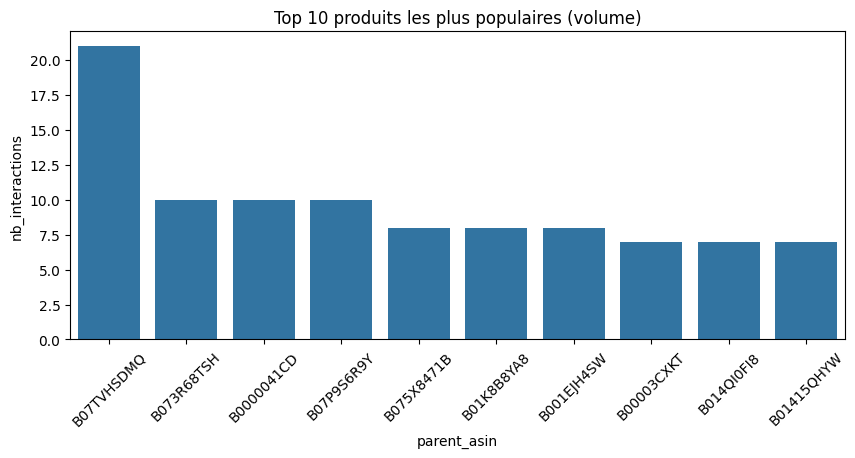

,parent_asin,nb_interactions
0,B07TVHSDMQ,21
1,B073R68TSH,10
2,B0000041CD,10
3,B07P9S6R9Y,10
4,B075X8471B,8
5,B01K8B8YA8,8
6,B001EJH4SW,8
7,B00003CXKT,7
8,B014QI0FI8,7
9,B01415QHYW,7


In [2]:
top_products_volume = (
    df.groupby("parent_asin")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="nb_interactions")
)
plt.figure(figsize=(10,4))
sns.barplot(
    data=top_products_volume.head(10),
    x="parent_asin",
    y="nb_interactions"
)
plt.title("Top 10 produits les plus populaires (volume)")
plt.xticks(rotation=45)
plt.show()


top_products_volume.head(10)


In [3]:
top_products_rating = (
    df.groupby("parent_asin")
      .agg(
          avg_rating=("rating", "mean"),
          nb_reviews=("rating", "count")
      )
      .sort_values("avg_rating", ascending=False)
      .reset_index()
)

top_products_rating.head(10)


,parent_asin,avg_rating,nb_reviews
0,0001529145,5.0,1
1,B074N2QSZT,5.0,1
2,B074NK4Q9T,5.0,1
3,B074Q111GY,5.0,1
4,B074QL2X4B,5.0,1
5,B074QL7WNM,5.0,1
6,B074QQHHDK,5.0,1
7,B074QQP2T2,5.0,1
8,B074S1P2MG,5.0,1
9,B074SJFRXR,5.0,1


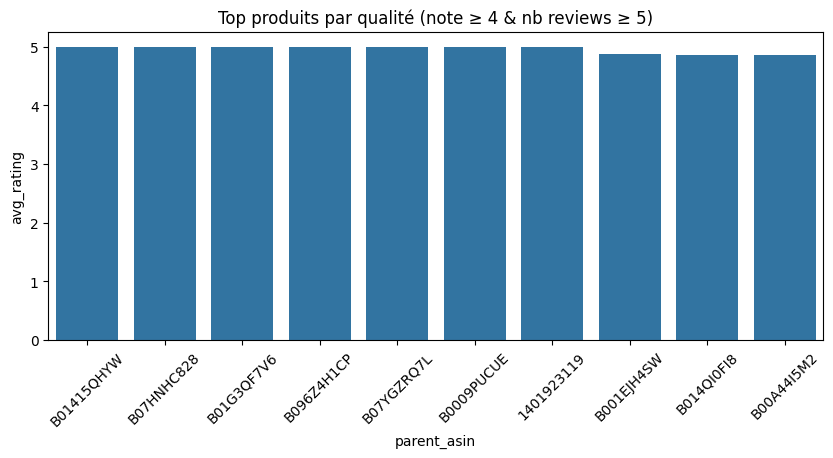

,parent_asin,avg_rating,nb_reviews
3536,B01415QHYW,5.000000,7
984,B07HNHC828,5.000000,5
3030,B01G3QF7V6,5.000000,5
4508,B096Z4H1CP,5.000000,5
5913,B07YGZRQ7L,5.000000,5
10176,B0009PUCUE,5.000000,5
13177,1401923119,5.000000,5
13318,B001EJH4SW,4.875000,8
13319,B014QI0FI8,4.857143,7
13320,B00A44I5M2,4.857143,7


In [4]:
MIN_REVIEWS = 5
MIN_RATING = 4.0

top_quality_products = top_products_rating[
    (top_products_rating["nb_reviews"] >= MIN_REVIEWS) &
    (top_products_rating["avg_rating"] >= MIN_RATING)
].sort_values(
    ["avg_rating", "nb_reviews"],
    ascending=[False, False]
)

plt.figure(figsize=(10,4))
sns.barplot(
    data=top_quality_products.head(10),
    x="parent_asin",
    y="avg_rating"
)
plt.title("Top produits par qualité (note ≥ 4 & nb reviews ≥ 5)")
plt.xticks(rotation=45)
plt.show()


top_quality_products.head(10)


In [5]:
top_products_by_category = (
    df.groupby(["category", "parent_asin"])
      .agg(
          avg_rating=("rating", "mean"),
          nb_reviews=("rating", "count")
      )
      .reset_index()
)


/var/folders/bh/8fmbpsz95z30k4gcxx0h08x00000gn/T/ipykernel_55549/3830982516.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_n_by_category)


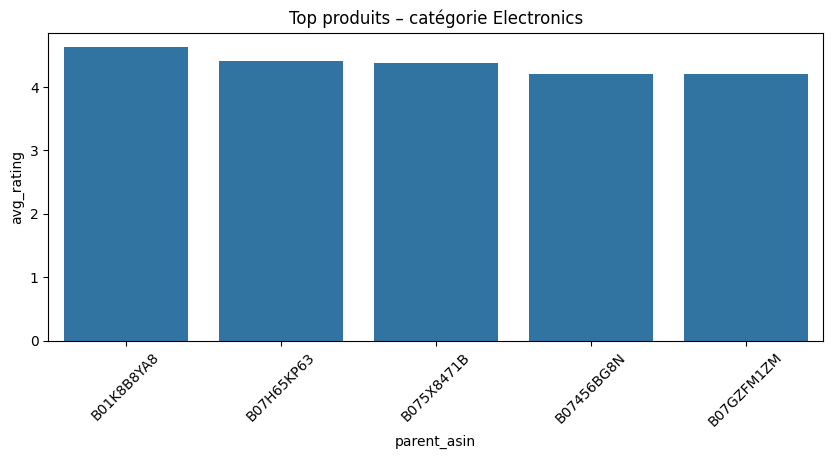

,category,parent_asin,avg_rating,nb_reviews
1514,Automotive,B07HNHC828,5.000000,5
1811,Automotive,B07YGZRQ7L,5.000000,5
559,Automotive,B00BYH6C1E,4.600000,5
1532,Automotive,B07JLQ24K9,4.600000,5
2085,Automotive,B08L7JNNV2,4.400000,5
9184,Cell_Phones_and_Accessories,B01415QHYW,5.000000,7
10830,Cell_Phones_and_Accessories,B096Z4H1CP,5.000000,5
11351,Cell_Phones_and_Accessories,B0BVLY92D8,4.800000,5
9897,Cell_Phones_and_Accessories,B07H2V5YLH,4.333333,6
9560,Cell_Phones_and_Accessories,B073R68TSH,4.300000,10


In [6]:
def top_n_by_category(df_cat, n=5):
    return (
        df_cat[df_cat["nb_reviews"] >= MIN_REVIEWS]
        .sort_values(
            ["avg_rating", "nb_reviews"],
            ascending=[False, False]
        )
        .head(n)
    )

top_by_category = (
    top_products_by_category
    .groupby("category", group_keys=False)
    .apply(top_n_by_category)
)

electronics_top = top_by_category[
    top_by_category["category"] == "Electronics"
]

plt.figure(figsize=(10,4))
sns.barplot(
    data=electronics_top,
    x="parent_asin",
    y="avg_rating"
)
plt.title("Top produits – catégorie Electronics")
plt.xticks(rotation=45)
plt.show()


top_by_category.head(10)


In [7]:
def recommend_popular(n=5):
    return top_products_volume.head(n)["parent_asin"].tolist()

def recommend_by_category(category, n=5):
    return (
        top_by_category[top_by_category["category"] == category]
        .head(n)["parent_asin"]
        .tolist()
    )


In [8]:
reference_date = df["timestamp"].max()

df["days_ago"] = (reference_date - df["timestamp"]).dt.days


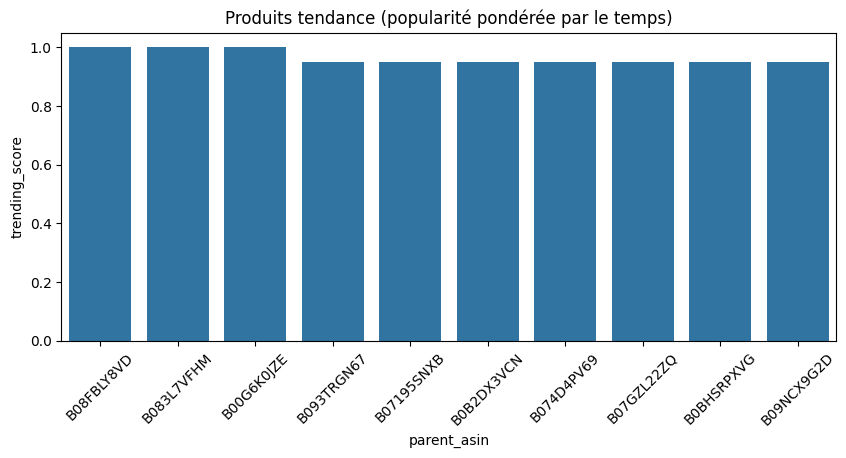

,parent_asin,trending_score
15869,B08FBLY8VD,1.000000
15152,B083L7VFHM,1.000000
8002,B00G6K0JZE,1.000000
17000,B093TRGN67,0.951533
11358,B07195SNXB,0.951229
18435,B0B2DX3VCN,0.951229
11660,B074D4PV69,0.951229
13083,B07GZL22ZQ,0.951229
18904,B0BHSRPXVG,0.951229
17881,B09NCX9G2D,0.951229


In [25]:
trending_products = (
    df.groupby("parent_asin")["time_weight"]
      .sum()
      .reset_index(name="trending_score")
      .sort_values("trending_score", ascending=False)
)

plt.figure(figsize=(10,4))
sns.barplot(
    data=trending_products.head(10),
    x="parent_asin",
    y="trending_score"
)
plt.title("Produits tendance (popularité pondérée par le temps)")
plt.xticks(rotation=45)
plt.show()


trending_products.head(10)


In [26]:
last_7_days = reference_date - pd.Timedelta(days=7)

weekly_trends = (
    df[df["timestamp"] >= last_7_days]
    .groupby("parent_asin")
    .size()
    .reset_index(name="weekly_interactions")
    .sort_values("weekly_interactions", ascending=False)
)

weekly_trends.head(10)


,parent_asin,weekly_interactions
0,0316219045,1
21,B0B4NJZDM6,1
23,B0BBDL7L73,1
24,B0BDZKCJMG,1
25,B0BFHVDPTG,1
26,B0BHN8ZHSK,1
27,B0BHSRPXVG,1
28,B0BKKW5PF4,1
29,B0BL6S9FGH,1
30,B0BMKP8X1H,1


In [27]:
last_30_days = reference_date - pd.Timedelta(days=30)

monthly_trends = (
    df[df["timestamp"] >= last_30_days]
    .groupby("parent_asin")
    .size()
    .reset_index(name="monthly_interactions")
    .sort_values("monthly_interactions", ascending=False)
)

monthly_trends.head(10)


,parent_asin,monthly_interactions
0,0063259990,1
146,B0BHN8ZHSK,1
124,B0B2DX3VCN,1
125,B0B37PWMVY,1
126,B0B3C2WZ86,1
127,B0B3T8GR2T,1
128,B0B4N5X5D7,1
129,B0B4NJZDM6,1
130,B0B5GRZ3FW,1
131,B0B5KNK89F,1


In [28]:
weekly_trends_by_category = (
    df[df["timestamp"] >= last_7_days]
    .groupby(["category", "parent_asin"])
    .size()
    .reset_index(name="weekly_interactions")
)


In [29]:
product_launch = (
    df.groupby("parent_asin")["timestamp"]
      .min()
      .reset_index(name="launch_date")
)


In [30]:
NEW_PRODUCT_DAYS = 90

product_launch["days_since_launch"] = (
    reference_date - product_launch["launch_date"]
).dt.days


In [31]:
product_stats = (
    df.groupby("parent_asin")
      .agg(
          avg_rating=("rating", "mean"),
          nb_reviews=("rating", "count")
      )
      .reset_index()
)

new_products = product_launch.merge(product_stats, on="parent_asin")
